In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime

In [2]:
dataset = baseClasses.Data()

In [27]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber='1')
mux2 = muxClasses.MUX(dataset=dataset, boardNumber='2')
mux3 = muxClasses.MUX(dataset=dataset, boardNumber='3')
mux4 = muxClasses.MUX(dataset=dataset, boardNumber='4')

s1 = sensorClasses.Sensor(dataset=dataset, id=39644)
s2 = sensorClasses.Sensor(dataset=dataset, id=39630)
s3 = sensorClasses.Sensor(dataset=dataset, id=39614)
s4 = sensorClasses.Sensor(dataset=dataset, id=40200)
s5 = sensorClasses.Sensor(dataset=dataset, id=39607)
s6 = sensorClasses.Sensor(dataset=dataset, id=39669)


# Equalization Board1 and Board2

TGradient sensors #39644 and #39630 at 3963 and 3727 mm high respectively. First pumps-off period just before ALL CE is turned on. PIPES configuration during the equalization time.

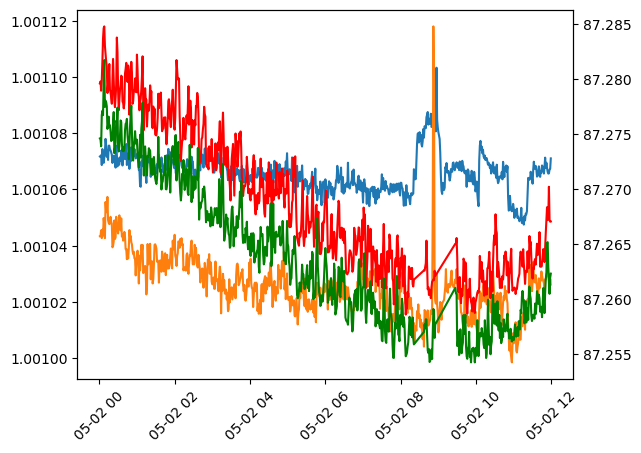

In [4]:
fig, axes = plt.subplots(1,1)
axes.plot(mux1.data.loc[(mux1.data.index>datetime.datetime(2024, 5, 2))&(mux1.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))])
axes.plot(mux2.data.loc[(mux2.data.index>datetime.datetime(2024, 5, 2))&(mux2.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))])
plt.xticks(rotation=45);
axes2 = axes.twinx()
axes2.plot(s1.data.loc[(s1.data.index>datetime.datetime(2024, 5, 2))&(s1.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))], 'r')
axes2.plot(s2.data.loc[(s2.data.index>datetime.datetime(2024, 5, 2))&(s2.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))], 'g')

In [5]:
T_CAL1 = s1.data.loc[(s1.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(s1.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]
T_CAL2 = s2.data.loc[(s2.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(s2.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]

s1.tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_132500_20241203_142500")
s2.tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_132500_20241203_142500")

deltaT1 = s1.cc
deltaT2 = s2.cc

I_M1 = mux1.data.loc[(mux1.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(mux1.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]
I_M2 = mux2.data.loc[(mux2.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(mux2.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]

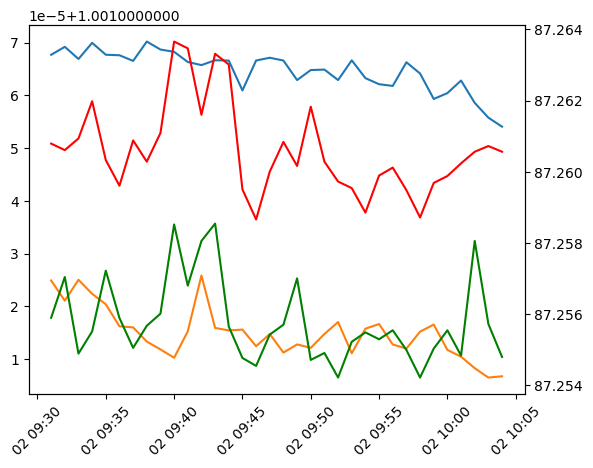

In [6]:
fig, axes = plt.subplots(1,1)
axes.plot(I_M1)
axes.plot(I_M2)
plt.xticks(rotation=45);
axes2 = axes.twinx()
axes2.plot(T_CAL1, 'r')
axes2.plot(T_CAL2, 'g')

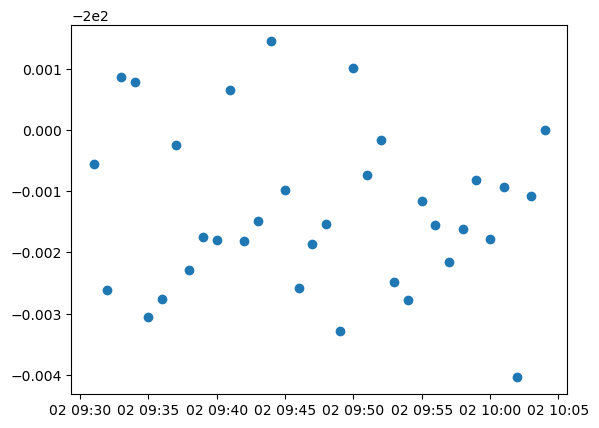

In [7]:
B2 = T_CAL2/(I_M2*(1e-3*(deltaT2-deltaT1) - T_CAL1/I_M1))
fig, axes = plt.subplots(1,1)
plt.plot(100*(B2.dropna()-1), "o")

In [8]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber='1')
mux2 = muxClasses.MUX(dataset=dataset, boardNumber='2')
mux3 = muxClasses.MUX(dataset=dataset, boardNumber='3')
mux4 = muxClasses.MUX(dataset=dataset, boardNumber='4')

s1 = sensorClasses.Sensor(dataset=dataset, id=39644).muxCorrection()
s2 = sensorClasses.Sensor(dataset=dataset, id=39630).muxCorrection()

-0.9999867197540319
0.9999867197540319


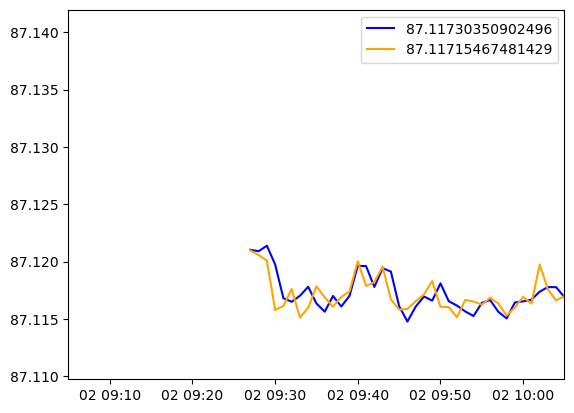

In [9]:
fig, axes = plt.subplots(1,1)
print(1/B2.mean())
print(1/abs(B2.mean()))
axes.plot(s1.data.loc[(s1.data.index>datetime.datetime(2024, 5, 2))&(s1.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))] + 1e-3*deltaT1, 'blue',
          label=(s1.data.loc[(s1.data.index>datetime.datetime(2024, 5, 2, 9, 5, 0))&(s1.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))] + 1e-3*deltaT1).mean())
axes.plot(abs((1/B2.mean()))*s2.data.loc[(s2.data.index>datetime.datetime(2024, 5, 2))&(s2.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))] + 1e-3*deltaT2, 'orange',
          label=(abs(1/B2.mean())*s2.data.loc[(s2.data.index>datetime.datetime(2024, 5, 2, 9, 5, 0))&(s2.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))] + 1e-3*deltaT2).mean())
axes.set_xlim(datetime.datetime(2024, 5, 2, 9, 5, 0), datetime.datetime(2024, 5, 2, 10, 5, 0, 0))
# axes.set_ylim(87.162, 87.175)
axes.legend()

# Equalization Board1 and Board3

TGradient sensor #39614 and APA2LAr4 sensor #44128 at 1131 and 1189 mm high respectively. First pumps-off period just before ALL CE is turned on. PIPES configuration during the equalization time.

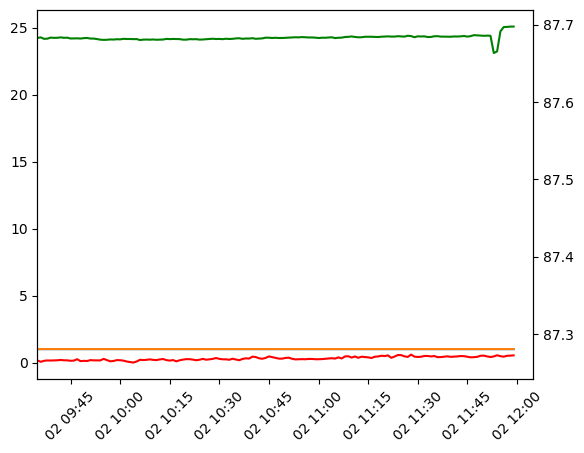

In [10]:
fig, axes = plt.subplots(1,1)
axes.plot(mux1.data.loc[(mux1.data.index>datetime.datetime(2024, 5, 2))&(mux1.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))])
axes.plot(mux3.data.loc[(mux2.data.index>datetime.datetime(2024, 5, 2))&(mux2.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))])
axes.set_xlim(datetime.datetime(2024, 5, 2, 9, 35, 0), datetime.datetime(2024, 5, 2, 12, 5, 0, 0))
plt.xticks(rotation=45);
axes2 = axes.twinx()
axes2.plot(s3.data.loc[(s3.data.index>datetime.datetime(2024, 5, 2))&(s3.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))], 'r')
axes2.plot(s4.data.loc[(s4.data.index>datetime.datetime(2024, 5, 2))&(s4.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))], 'g')

In [11]:
T_CAL1 = s3.data.loc[(s3.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(s3.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]
T_CAL2 = s4.data.loc[(s4.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(s4.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]

s3.tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_132500_20241203_142500")
s4.tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_132500_20241203_142500")

deltaT1 = s3.cc
deltaT2 = s4.cc

print(deltaT1)
print(deltaT2)

I_M1 = mux1.data.loc[(mux1.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(mux1.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]
I_M2 = mux3.data.loc[(mux3.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(mux3.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]

-41.17909783464626
208.7685775891353


-1.0000195188684993


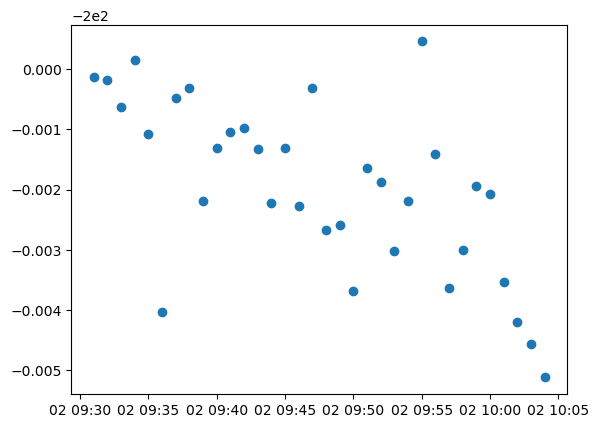

In [12]:
B3 = T_CAL2/(I_M2*(1e-3*(deltaT2-deltaT1) - T_CAL1/I_M1))
print(B3.mean())
fig, axes = plt.subplots(1,1)
plt.plot(100*(B3.dropna()-1), "o")

In [13]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber='1')
mux2 = muxClasses.MUX(dataset=dataset, boardNumber='2')
mux3 = muxClasses.MUX(dataset=dataset, boardNumber='3')
mux4 = muxClasses.MUX(dataset=dataset, boardNumber='4')

s3 = sensorClasses.Sensor(dataset=dataset, id=39614).muxCorrection()
s4 = sensorClasses.Sensor(dataset=dataset, id=40200).muxCorrection()

ERROR: Board (11) not found
ERROR: Board (11) not found
ERROR: Board (11) not found


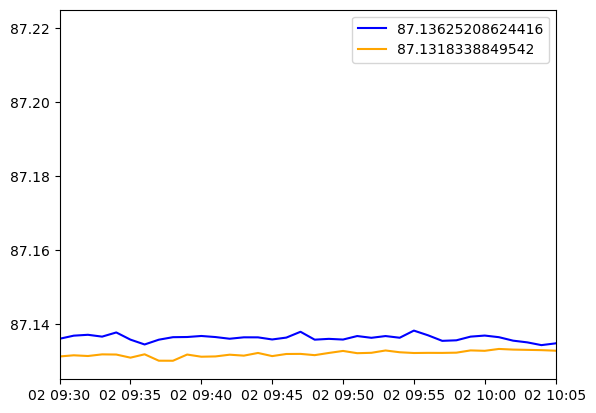

In [14]:
fig, axes = plt.subplots(1,1)
axes.plot(s3.data.loc[(s3.data.index>datetime.datetime(2024, 5, 2))&(s3.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))] + 1e-3*deltaT1, 'blue',
          label=(s3.data.loc[(s3.data.index>datetime.datetime(2024, 5, 2, 9, 5, 0))&(s3.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))] + 1e-3*deltaT1).mean())
axes.plot(abs(1/B3.mean())*s4.data.loc[(s4.data.index>datetime.datetime(2024, 5, 2))&(s4.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))] + 1e-3*deltaT2, 'orange',
          label=(abs(1/B3.mean())*s4.data.loc[(s4.data.index>datetime.datetime(2024, 5, 2, 9, 5, 0))&(s4.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))] + 1e-3*deltaT2).mean()
          )
axes.set_xlim(datetime.datetime(2024, 5, 2, 9, 30, 0), datetime.datetime(2024, 5, 2, 10, 5, 0, 0))
axes.set_ylim(87.125, 87.225)
axes.legend()

# Equalization Board1 and Board4

TGradient sensor #39607 and 4-U sensor #39669 at 305 and 186 mm high respectively. First pumps-off period just before ALL CE is turned on. PIPES configuration during the equalization time.

In [15]:
import json

[-42.35044629306424, -43.48834883748543, -38.964718710731006, -36.85612425583706, -42.22766808206288, -43.36557062648407, -38.84194049972966, -36.733346044835685, -5413.507133872788, -5414.645036417209, -5410.121406290455, -5408.012811835561, -42.43966875106408, -43.57757129548528, -39.05394116873086, -36.945346713836884, -42.23850134980725, -43.376403894228446, -38.85277376747403, -36.74417931258006, -42.439396815807065, -43.57729936022826, -39.05366923347383, -36.945074778579865, -42.09831570751541, -43.236218251936606, -38.712588125182194, -36.603993670288226, -41.96556940677293, -43.10347195119412, -38.579841824439704, -36.471247369545736]


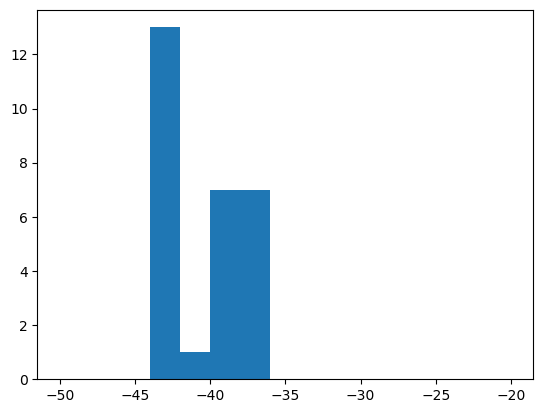

In [16]:
with open("/eos/user/j/jcapotor/RTDdata/calib/PIPE_TREE.json", "r") as f:
    data = json.load(f)
    # print(data["39610"]["39669"])
    print(data["39607"]["39669"])

plt.hist(data["39607"]["39669"], range=(-50, -20), bins=15);

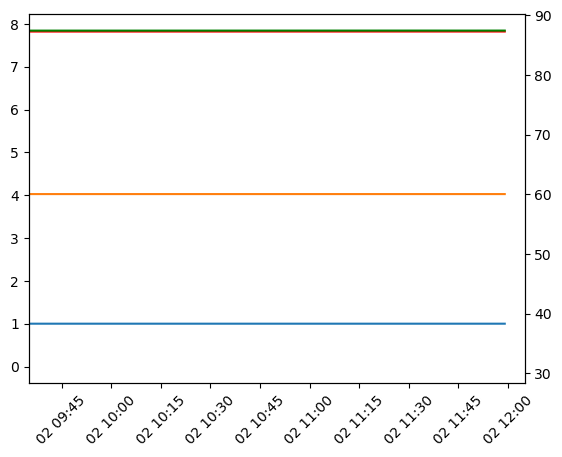

In [28]:
fig, axes = plt.subplots(1,1)
axes.plot(mux1.data.loc[(mux1.data.index>datetime.datetime(2024, 5, 2))&(mux1.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))])
axes.plot(mux4.data.loc[(mux4.data.index>datetime.datetime(2024, 5, 2))&(mux4.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))])
axes.set_xlim(datetime.datetime(2024, 5, 2, 9, 35, 0), datetime.datetime(2024, 5, 2, 12, 5, 0, 0))
plt.xticks(rotation=45);
axes2 = axes.twinx()
axes2.plot(s5.data.loc[(s5.data.index>datetime.datetime(2024, 5, 2))&(s5.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))], 'r')
axes2.plot(s6.data.loc[(s6.data.index>datetime.datetime(2024, 5, 2))&(s6.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))], 'g')

In [29]:
T_CAL1 = s5.data.loc[(s5.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(s5.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]
T_CAL2 = s6.data.loc[(s6.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(s6.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]

s5.tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_132500_20241203_142500")
s6.tempCalibration(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_132500_20241203_142500")

deltaT1 = s5.cc
deltaT2 = -36

print(deltaT1)
print(deltaT2)

I_M1 = mux1.data.loc[(mux1.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(mux1.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]
I_M2 = mux4.data.loc[(mux4.data.index>datetime.datetime(2024, 5, 2, 9, 30, 0))&(mux4.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))]

ERROR: SensorID (39669) not found in calibration (SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_132500_20241203_142500)
-15.101025838852062
-36


-0.2488933366361899


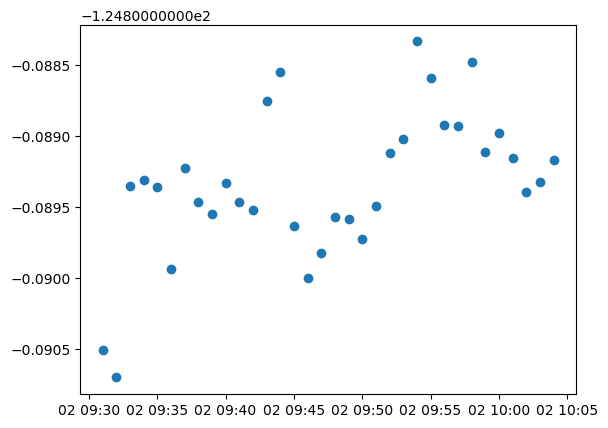

In [30]:
B4 = T_CAL2/(I_M2*(1e-3*(deltaT2-deltaT1) - T_CAL1/I_M1))
print(B4.mean())
fig, axes = plt.subplots(1,1)
plt.plot(100*(B4.dropna()-1), "o")

In [31]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber='1')
mux2 = muxClasses.MUX(dataset=dataset, boardNumber='2')
mux3 = muxClasses.MUX(dataset=dataset, boardNumber='3')
mux4 = muxClasses.MUX(dataset=dataset, boardNumber='4')

s5 = sensorClasses.Sensor(dataset=dataset, id=39607).muxCorrection()
s6 = sensorClasses.Sensor(dataset=dataset, id=39669).muxCorrection()

ERROR: Board (11) not found


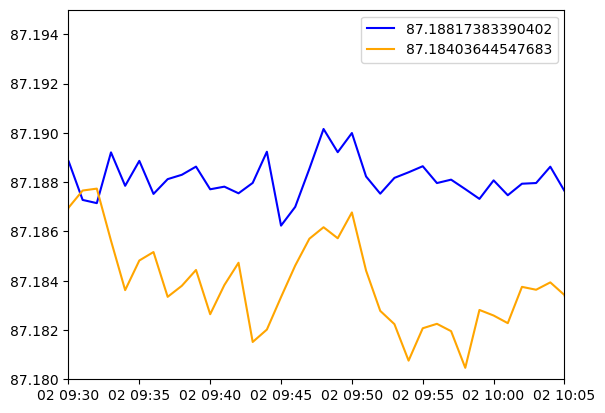

In [32]:
fig, axes = plt.subplots(1,1)
axes.plot(s5.data.loc[(s5.data.index>datetime.datetime(2024, 5, 2))&(s5.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))] + 1e-3*deltaT1, 'blue',
          label=(s5.data.loc[(s5.data.index>datetime.datetime(2024, 5, 2, 9, 5, 0))&(s5.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))] + 1e-3*deltaT1).mean())
axes.plot(abs(1/B4.mean())*s6.data.loc[(s6.data.index>datetime.datetime(2024, 5, 2))&(s6.data.index<datetime.datetime(2024, 5, 2, 12, 0, 0, 0))] + 1e-3*deltaT2, 'orange',
          label=(abs(1/B4.mean())*s6.data.loc[(s6.data.index>datetime.datetime(2024, 5, 2, 9, 5, 0))&(s6.data.index<datetime.datetime(2024, 5, 2, 10, 5, 0, 0))] + 1e-3*deltaT2).mean()
          )
axes.set_xlim(datetime.datetime(2024, 5, 2, 9, 30, 0), datetime.datetime(2024, 5, 2, 10, 5, 0, 0))
axes.set_ylim(87.180, 87.195)
axes.legend()

In [ ]:
equalisation = {
    1:1,
    2:B2.mean(),
    3:B3.mean(),
    4:B4.mean()
}

In [83]:
import pickle

with open("/eos/user/j/jcapotor/RTDdata/corrections/equalisation.pkl", "wb") as f:
    pickle.dump(equalisation, f)